In [17]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D,InputLayer
from tensorflow.keras.utils import to_categorical
from keras.applications.vgg16 import VGG16
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [2]:
#load cifar10 dataset
(x_train,y_train), (x_test,y_test)=cifar10.load_data()

c:\Users\divyadamodaran\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


In [3]:
#normalize the pixel values btween 0 and 1
x_train = x_train / 255.0
x_test = x_test / 255.0

In [4]:
#one hot encode the labels (cifar10 has 10 classes)
y_train=to_categorical(y_train,10)
y_test=to_categorical(y_test,10)

In [5]:
#load vgg16 model pre trained on imagnet without the top kayers
base_model=VGG16(weights='imagenet',include_top=False)

In [6]:
#freeze the layers of vgg16
for layer in base_model.layers:
    layer.trainable=False
    

In [18]:

model=Sequential()
model.add(InputLayer(input_shape=(32,32,3)))
model.add(base_model)
model.add(GlobalAveragePooling2D())
model.add(Dense(256,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10,activation='softmax'))
model.compile(optimizer=Adam(learning_rate=0.0001),loss='categorical_crossentropy',metrics=['accuracy'])
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [12]:
datagen=ImageDataGenerator(
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

In [13]:
batch_size=64
epochs=3
train_generator=datagen.flow(x_train,y_train,batch_size=batch_size)

In [14]:
history=model.fit(train_generator,
                  steps_per_epoch=x_train.shape[0]//batch_size,
                  epochs=epochs,
                  validation_data=(x_test,y_test))

Epoch 1/3
781/781 ━━━━━━━━━━━━━━━━━━━━ 167s 213ms/step - accuracy: 0.2916 - loss: 1.9864 - val_accuracy: 0.4567 - val_loss: 1.6267
Epoch 2/3
  1/781 ━━━━━━━━━━━━━━━━━━━━ 3:52 298ms/step - accuracy: 0.4219 - loss: 1.7318

c:\Users\divyadamodaran\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


781/781 ━━━━━━━━━━━━━━━━━━━━ 37s 46ms/step - accuracy: 0.4219 - loss: 1.7318 - val_accuracy: 0.4568 - val_loss: 1.6265
Epoch 3/3
781/781 ━━━━━━━━━━━━━━━━━━━━ 176s 226ms/step - accuracy: 0.4239 - loss: 1.6509 - val_accuracy: 0.4927 - val_loss: 1.4818


In [15]:
#evaluate the model
test_loss,test_acc=model.evaluate(x_test,y_test,verbose=2)
print(f'Test accuracy : {test_acc:.4f}')

313/313 - 29s - 91ms/step - accuracy: 0.4927 - loss: 1.4818
Test accuracy : 0.4927


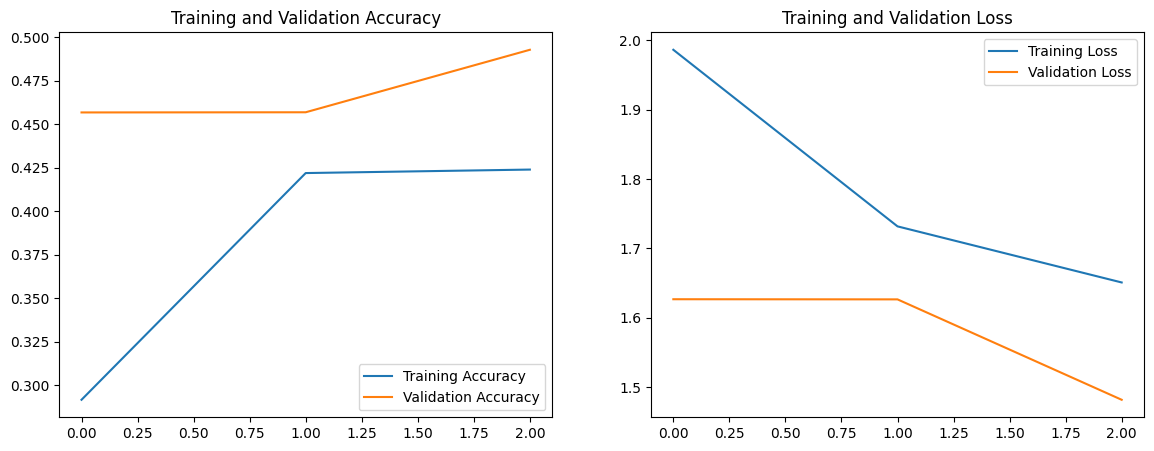

In [16]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.savefig('./foo.png')
plt.show()